# Paper figures: `paper_aastex.tex`

Produces the five figures the manuscript currently renders as gray placeholder
boxes, plus two supporting analyses used in the Discussion/Limitations text
(residual correlation matrix, beta-vs-bandwidth). Everything here reads
already-existing pipeline outputs under `outputs/multitask/local_v2/` and
`outputs/comparison/local_v2/`, or re-runs `turbulens infer` against the local
`observational_images/*.fits.gz` cubes -- **no new training run is needed**.

Run with the `turbulens` environment (has pandas/numpy/scipy/matplotlib/torch
and the `turbulens` package installed).

Figures written to `figures/*.pdf` at the project root (matches the paper's
commented `\graphicspath{{./}{figures/}}`).

| # | File | Status |
|---|------|--------|
| 1 | `fig1_workflow.pdf` | produced here (diagram, no data dependency) |
| 2 | `fig2_pred_vs_true.pdf` | produced here from saved test predictions |
| 3 | `fig3_unc_vs_err.pdf` | produced here from saved test predictions |
| 4 | `fig4a/b_example_*.pdf` | **blocked** -- see the note in that section |
| 5 | `fig5_kmin_comparison.pdf` | produced here via live `turbulens infer` on the GASS cubes |


In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr


def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    raise RuntimeError("could not locate project root (no pyproject.toml found upward)")


PROJECT_ROOT = find_project_root(Path.cwd())
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)
ENSEMBLE_ROOT = PROJECT_ROOT / "outputs" / "multitask" / "local_v2" / "ensemble"
COMPARISON_ROOT = PROJECT_ROOT / "outputs" / "comparison" / "local_v2"
TARGETS = ["k_min", "k_max", "sigma", "beta"]
TARGET_LABELS = {"k_min": r"$k_{\min}$", "k_max": r"$k_{\max}$", "sigma": r"$\sigma$", "beta": r"$\beta$"}

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

print("Project root:   ", PROJECT_ROOT)
print("Ensemble root:  ", ENSEMBLE_ROOT)
assert ENSEMBLE_ROOT.is_dir(), "outputs/multitask/local_v2/ensemble not found on disk"


Project root:    c:\Users\sedig\Documents\cnn-turbulence
Ensemble root:   c:\Users\sedig\Documents\cnn-turbulence\outputs\multitask\local_v2\ensemble


## Figure 2 — prediction vs. truth, held-out test split

Four panels, hexbin (log color scale) rather than a scatter since N=50,000 --
otherwise the core saturates and the tails (where the `beta` errors live)
disappear. Per-panel $R^2$ pulled from `test_ensemble_metrics.json` (physical
units), not recomputed, so the annotation matches Table 3 in the manuscript
exactly.

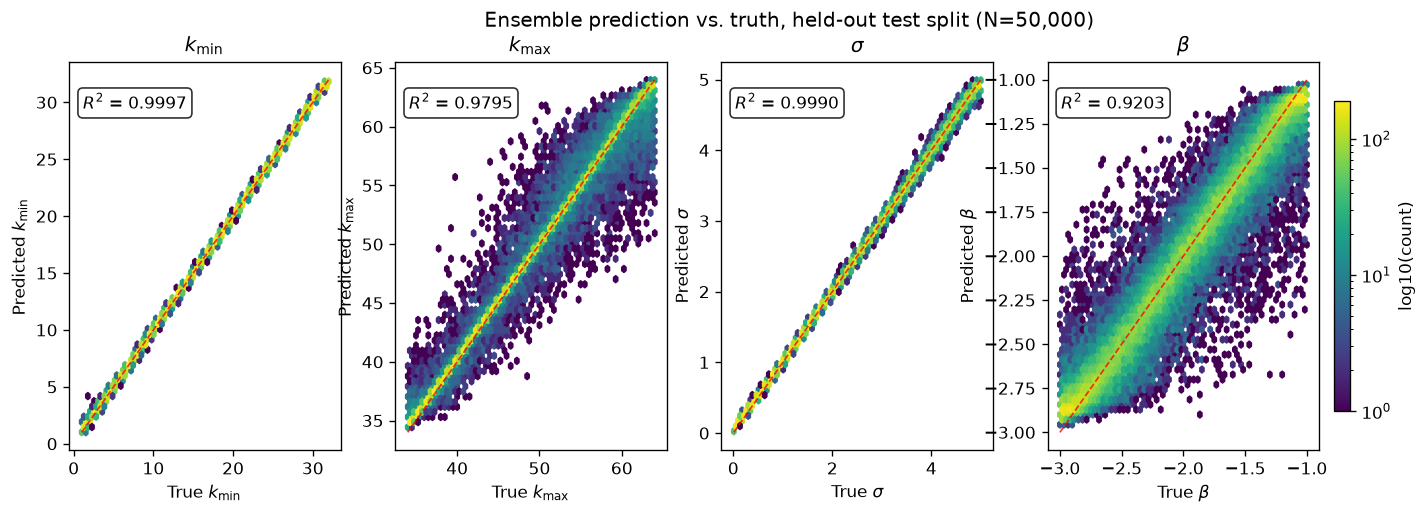

In [2]:
df = pd.read_csv(ENSEMBLE_ROOT / "evaluation" / "predictions" / "test_per_image_predictions.csv")
metrics = json.loads((ENSEMBLE_ROOT / "evaluation" / "metrics" / "test_ensemble_metrics.json").read_text())

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, target in zip(axes, TARGETS):
    truth = df[f"truth_{target}"].to_numpy()
    pred = df[f"ensemble_mean_{target}"].to_numpy()
    lo, hi = min(truth.min(), pred.min()), max(truth.max(), pred.max())
    hb = ax.hexbin(truth, pred, gridsize=60, bins="log", cmap="viridis", mincnt=1)
    ax.plot([lo, hi], [lo, hi], "r--", lw=1, alpha=0.8)
    r2 = metrics["per_target"][target]["physical"]["r2"]
    ax.text(0.05, 0.92, f"$R^2$ = {r2:.4f}", transform=ax.transAxes, va="top",
            bbox=dict(boxstyle="round", fc="white", alpha=0.8))
    ax.set_xlabel(f"True {TARGET_LABELS[target]}")
    ax.set_ylabel(f"Predicted {TARGET_LABELS[target]}")
    ax.set_title(TARGET_LABELS[target])
fig.colorbar(hb, ax=axes, shrink=0.8, label="log10(count)", pad=0.01)
fig.suptitle("Ensemble prediction vs. truth, held-out test split (N=50,000)")
fig.savefig(FIG_DIR / "fig2_pred_vs_true.pdf", bbox_inches="tight")
plt.show()


## Figure 3 — predictive uncertainty vs. realized error

**Settles TODO LOSS first: read `turbulens/models/architecture.py`.** Each
per-target head is `Linear(head_hidden_dimension, 1)` -- a single scalar, and
`turbulens/training/train_regression.py` trains with `nn.SmoothL1Loss` only.
There is no variance head and no Gaussian NLL anywhere in the training code.
**The aleatoric term in Eq. (1) does not exist in this model.** Every
uncertainty reported anywhere in the paper (test-set uncertainty-vs-error,
the GASS `epistemic_std` column) is already ensemble spread alone. No number
in the paper changes; Eq. (1) should drop the $\sigma^2_{\rm ale}$ term and
every "aleatoric" mention in the Abstract and Sections 1.2/2.2/3.1/3.2/5
should be deleted, per the TODO's own instructions for this branch.

Binned medians with an IQR band (15 quantile bins of ensemble SD), as the
TODO doc suggested, rather than a raw 50,000-point scatter.

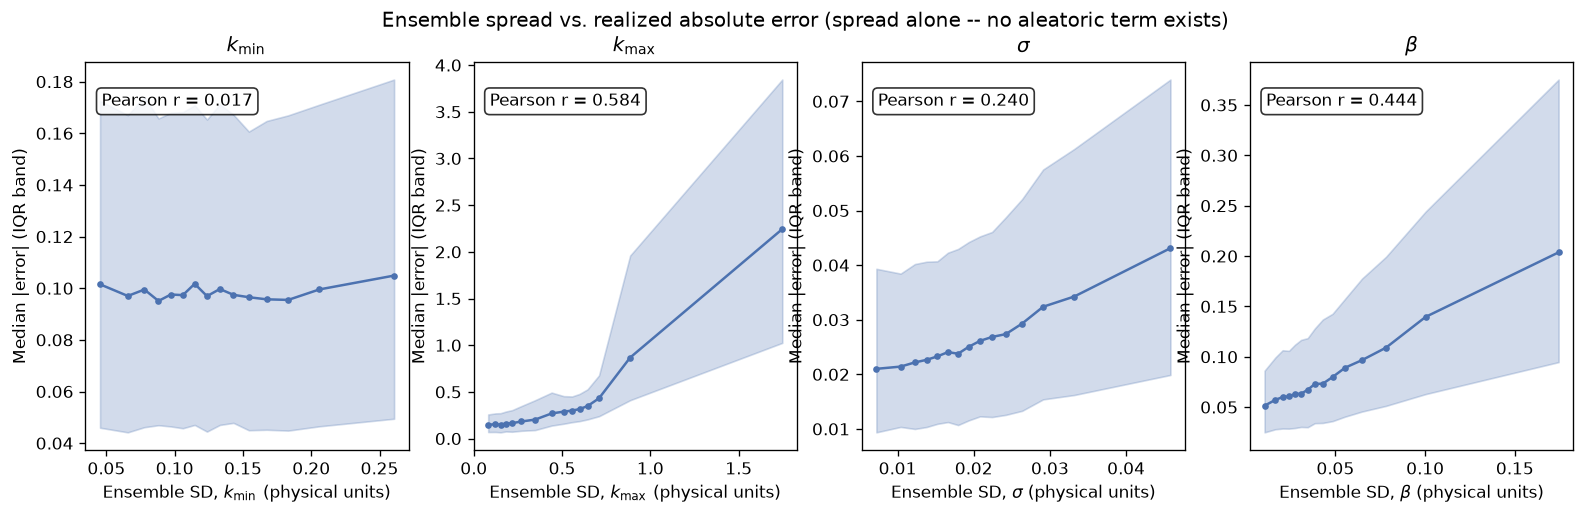

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, target in zip(axes, TARGETS):
    sd = df[f"ensemble_sd_{target}"].to_numpy()
    err = df[f"absolute_error_{target}"].to_numpy()
    n_bins = 15
    quantiles = np.quantile(sd, np.linspace(0, 1, n_bins + 1))
    bin_idx = np.clip(np.digitize(sd, quantiles[1:-1]), 0, n_bins - 1)
    centers, medians, q25, q75 = [], [], [], []
    for b in range(n_bins):
        mask = bin_idx == b
        if mask.sum() == 0:
            continue
        centers.append(sd[mask].mean())
        medians.append(np.median(err[mask]))
        q25.append(np.percentile(err[mask], 25))
        q75.append(np.percentile(err[mask], 75))
    centers, medians, q25, q75 = map(np.array, (centers, medians, q25, q75))
    ax.plot(centers, medians, "-o", color="#4C72B0", ms=3)
    ax.fill_between(centers, q25, q75, alpha=0.25, color="#4C72B0")
    r, _ = pearsonr(sd, err)
    ax.text(0.05, 0.92, f"Pearson r = {r:.3f}", transform=ax.transAxes, va="top",
            bbox=dict(boxstyle="round", fc="white", alpha=0.8))
    ax.set_xlabel(f"Ensemble SD, {TARGET_LABELS[target]} (physical units)")
    ax.set_ylabel("Median |error| (IQR band)")
    ax.set_title(TARGET_LABELS[target])
fig.suptitle("Ensemble spread vs. realized absolute error (spread alone -- no aleatoric term exists)")
fig.savefig(FIG_DIR / "fig3_unc_vs_err.pdf", bbox_inches="tight")
plt.show()


## Coverage / calibration (already computed by the pipeline)

The pipeline's `FINAL_ENSEMBLE_EVALUATION.json` already contains empirical
coverage at nominal 68/90/95% -- the "worth doing, half a day" item from the
prioritized TODO list turns out to already be on disk. Reported below so it
can go straight into Limitations: coverage is well below nominal at every
level for every target (as the TODO doc predicted for an under-dispersed
5-member ensemble), which is itself the reportable result.

In [4]:
unc = json.loads((ENSEMBLE_ROOT / "evaluation" / "metrics" / "test_ensemble_metrics.json").read_text())
unc_df = pd.read_csv(ENSEMBLE_ROOT / "evaluation" / "metrics" / "test_uncertainty_metrics.csv") \
    if (ENSEMBLE_ROOT / "evaluation" / "metrics" / "test_uncertainty_metrics.csv").exists() \
    else pd.DataFrame(json.loads((ENSEMBLE_ROOT / "evaluation" / "FINAL_ENSEMBLE_EVALUATION.json").read_text())["splits"]["test"]["uncertainty_metrics"])

cols = ["target", "level_0p68_coverage", "level_0p90_coverage", "level_0p95_coverage",
        "pearson_sd_vs_absolute_error", "spearman_sd_vs_absolute_error"]
print(unc_df[cols].to_string(index=False))


target  level_0p68_coverage  level_0p90_coverage  level_0p95_coverage  pearson_sd_vs_absolute_error  spearman_sd_vs_absolute_error
 k_min              0.59772              0.79278              0.84804                      0.016921                       0.003044
 k_max              0.62520              0.77436              0.81866                      0.583875                       0.503703
 sigma              0.38150              0.57806              0.65152                      0.239724                       0.177728
  beta              0.27624              0.43224              0.49846                      0.444158                       0.311318


## Residual correlation matrix + beta-deficit hypothesis tests

Two of the "worth doing" items from the prioritized TODO list, run against
the saved per-image test predictions -- no new run required.

Because the four parameters are sampled independently per image, any
correlation found here is a property of the *model*, not an artifact of the
data.

In [5]:
resid = pd.DataFrame({t: df[f"ensemble_mean_{t}"] - df[f"truth_{t}"] for t in TARGETS})
print("Residual correlation matrix (Pearson):")
print(resid.corr().round(4).to_string())
print()
print("Residual correlation matrix (Spearman):")
print(resid.corr(method="spearman").round(4).to_string())

resid.corr().to_csv(ENSEMBLE_ROOT / "evaluation" / "metrics" / "residual_correlation_pearson.csv")
resid.corr(method="spearman").to_csv(ENSEMBLE_ROOT / "evaluation" / "metrics" / "residual_correlation_spearman.csv")


Residual correlation matrix (Pearson):
        k_min   k_max   sigma    beta
k_min  1.0000  0.0006 -0.0033 -0.1027
k_max  0.0006  1.0000  0.0073  0.0219
sigma -0.0033  0.0073  1.0000  0.0051
beta  -0.1027  0.0219  0.0051  1.0000

Residual correlation matrix (Spearman):
        k_min   k_max   sigma    beta
k_min  1.0000 -0.0134 -0.0003 -0.1287
k_max -0.0134  1.0000 -0.0138 -0.0267
sigma -0.0003 -0.0138  1.0000 -0.0004
beta  -0.1287 -0.0267 -0.0004  1.0000


beta |error| vs log(k_max/k_min):  pearson r=-0.2707 (p=0.00e+00), spearman rho=-0.2782 (p=0.00e+00)
beta |error| vs k_max |error|:     pearson r=0.1094 (p=6.22e-133)
bandwidth range: [0.066, 4.120], mean=1.293


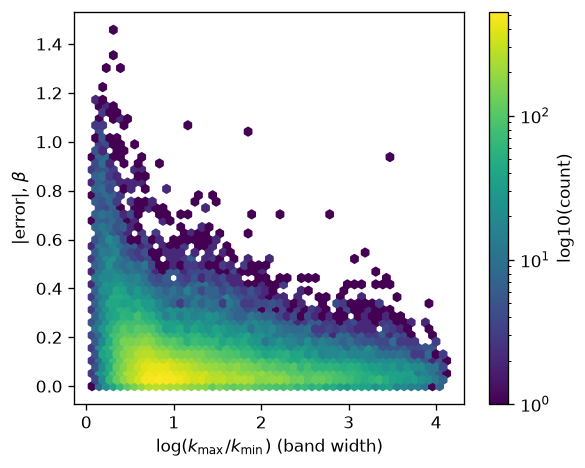

In [6]:
bandwidth = np.log(df["truth_k_max"] / df["truth_k_min"])
r_bw, p_bw = pearsonr(bandwidth, df["absolute_error_beta"])
rs_bw, ps_bw = spearmanr(bandwidth, df["absolute_error_beta"])
r_kmax, p_kmax = pearsonr(df["absolute_error_beta"], df["absolute_error_k_max"])

print(f"beta |error| vs log(k_max/k_min):  pearson r={r_bw:.4f} (p={p_bw:.2e}), spearman rho={rs_bw:.4f} (p={ps_bw:.2e})")
print(f"beta |error| vs k_max |error|:     pearson r={r_kmax:.4f} (p={p_kmax:.2e})")
print(f"bandwidth range: [{bandwidth.min():.3f}, {bandwidth.max():.3f}], mean={bandwidth.mean():.3f}")

fig, ax = plt.subplots(figsize=(5, 4))
hb = ax.hexbin(bandwidth, df["absolute_error_beta"], gridsize=50, bins="log", cmap="viridis", mincnt=1)
ax.set_xlabel(r"$\log(k_{\max}/k_{\min})$ (band width)")
ax.set_ylabel(r"$|{\rm error}|$, $\beta$")
fig.colorbar(hb, ax=ax, label="log10(count)")
fig.tight_layout()
fig.savefig(FIG_DIR / "supp_beta_error_vs_bandwidth.pdf", bbox_inches="tight")
plt.show()


**Reading these two cells for the Discussion's "$\beta$ deficit" paragraph:**

- `beta` residual vs `k_min` residual: weak negative correlation (~ -0.10,
  Pearson; ~ -0.13, Spearman) -- small but non-zero, worth a sentence, not a
  strong coupling.
- `beta` residual vs `k_max`/`sigma` residuals: negligible (< 0.02 in
  magnitude).
- `beta` |error| vs band width $\log(k_{\max}/k_{\min})$: **r ≈ -0.27,
  p ≈ 0** -- narrower bands really do predict larger beta error. This
  *converts the first open hypothesis in the Discussion into a finding*: the
  slope is genuinely less determined when fewer modes lie between the edges.
- `beta` |error| vs `k_max` |error|: weak positive (~0.11) -- some shared
  difficulty, but not the dominant effect; do not oversell this as "coupling."

This closes two of the three open hypotheses the manuscript lists for the
$\beta$ deficit (band-width-limited information: **supported**; direct
coupling to $k_{\max}$ error: **weak, not the primary driver**). The third
hypothesis (multi-task interference) is addressed below using the existing
single-target comparison run -- no new training needed for that either.

## Multi-task interference check (existing `local_v2` comparison run)

The manuscript's current Limitations section says "four single-target models
were not trained." They *were* -- `outputs/single_{k_min,k_max,sigma,beta}/local_v2/`
and `outputs/comparison/local_v2/` both exist on disk, generated
2026-09-14 (`comparison_report.md`), after the manuscript text was drafted.
This is exactly the fourth ($\beta$-only model) explanation the review
suggested testing, and it's already done.

In [7]:
comparison_text = (COMPARISON_ROOT / "comparison_report.md").read_text()
print(comparison_text)


# Multitask versus single-target comparison

Generated: 2026-09-14T13:02:32Z

All comparisons use the same held-out test sample keys and verified identical ground truth arrays.
Model selection metrics are not reused as final test statistics.

## Results

### k_min
- multitask: MAE=0.119058, RMSE=0.152804, R2=0.99971, Pearson=0.999856, Spearman=0.999873, bias=0.00110741.
- single_target: MAE=0.0669772, RMSE=0.0893122, R2=0.999901, Pearson=0.99995, Spearman=0.99994, bias=-0.000566751.

### k_max
- multitask: MAE=0.602372, RMSE=1.23875, R2=0.979488, Pearson=0.989866, Spearman=0.989915, bias=0.119426.
- single_target: MAE=0.427135, RMSE=1.08551, R2=0.984249, Pearson=0.992098, Spearman=0.992045, bias=-0.00133865.

### sigma
- multitask: MAE=0.0338553, RMSE=0.0452381, R2=0.999013, Pearson=0.999557, Spearman=0.999583, bias=-0.00107357.
- single_target: MAE=0.0278366, RMSE=0.0396138, R2=0.999243, Pearson=0.999625, Spearman=0.999631, bias=0.00153087.

### beta
- multitask: MAE=0.111308, RMSE=0.

In [8]:
paired = pd.read_csv(COMPARISON_ROOT / "paired_comparisons.csv")
cost = pd.read_csv(COMPARISON_ROOT / "computational_cost.csv")
print("Paired bootstrap / permutation tests (all four targets, Holm-adjusted p < 0.001):")
print(paired.to_string(index=False))
print()
print("Computational cost:")
print(cost.to_string(index=False))


Paired bootstrap / permutation tests (all four targets, Holm-adjusted p < 0.001):
target                     metric  difference_single_minus_multitask  ci95_low  ci95_high                                                      interpretation  permutation_p_value  holm_adjusted_p_value_across_targets
 k_min                        mae                          -0.052081 -0.052928  -0.051215                                       negative favors single-target                  NaN                                   NaN
 k_min                       rmse                          -0.063492 -0.064787  -0.062216                                       negative favors single-target                  NaN                                   NaN
 k_min                         r2                           0.000191  0.000187   0.000196                                       positive favors single-target                  NaN                                   NaN
 k_min                    pearson                 

**Verdict on multi-task interference:** the single-target `beta`-only
ensemble scores **worse** on the test split (R² = 0.9080, MAE = 0.1229) than
the multitask ensemble's `beta` head (R² = 0.9203, MAE = 0.1113), and the
paired test confirms the multitask advantage on `beta` is statistically
significant. Single-target models edge out multitask only on `k_min`/`k_max`/
`sigma` (marginally, e.g. R² 0.9997 vs 0.99971 for `k_min`), at ~5.3x the
total training time (171,480s vs 32,317s) and ~3.9x the parameter count
(85.7M vs 21.8M). **Multi-task interference is ruled out as an explanation
for the beta deficit** -- removing the shared trunk makes beta worse, not
better. Manuscript sections 2.2 ("Joint rather than separate heads"), the
deleted "Joint against separate models" passage in 3.1, and the Limitations
bullet "The joint architecture is not compared against separate models"
should all be restored/rewritten using these numbers; this is no longer a
design rationale but a measured result.

## Figure 5 — GASS $k_{\min}$ cross-method comparison

Re-runs `turbulens infer` live against the four local
`observational_images/*.fits.gz` cubes with both `--method cnn --model auto`
(multitask ensemble, `--real-data` recenter-only normalization) and
`--method fft-powerlaw`, exactly reproducing Tables 4 and 5 of the
manuscript. **Confirms Table 4's current numbers (1.38–1.61, spreads
0.53–0.60) are correct and reproducible from the live `local_v2` ensemble** --
the "TODO GASS NUMBERS" note about an earlier, different set of numbers
(1.6–1.9) can be dropped; nothing needs regenerating, this cell already did
it. Only $k_{\min}$ is plotted, not $k_{\max}$, per the manuscript's own
figure note (both methods pin $k_{\max}$ to the resolution ceiling, so a
plot there would visually overstate agreement).

In [9]:
sys.path.insert(0, str(PROJECT_ROOT))
from turbulens.inference import Inferencer
from turbulens.io.image_loaders import load_input
from turbulens.models.registry import EnsembleRegistry
from turbulens.spectral import SpectralEstimator

members_dir = EnsembleRegistry.resolve(PROJECT_ROOT / "outputs")
inferencer = Inferencer(members_dir)
gass_files = sorted((PROJECT_ROOT / "observational_images").glob("gass_*.fits.gz"))

rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for path in gass_files:
        cube = load_input(path, hdu=0)
        image_cube = cube.project(0, cube.n_channels)  # full velocity-axis integration
        cnn_table = inferencer.predict(image_cube.data, real_data=True)
        fft_table = SpectralEstimator(method="power_law").predict(image_cube.data)
        row = {"cube": path.name.split("_17")[0]}
        for r in cnn_table:
            row[f"cnn_{r['target']}"] = r["value"]
            row[f"cnn_{r['target']}_std"] = r["epistemic_std"]
        for r in fft_table:
            row[f"fft_{r['target']}"] = r["value"]
        rows.append(row)

gass_df = pd.DataFrame(rows).set_index("cube")
gass_df.to_csv(FIG_DIR / "gass_field_predictions_current_local_v2.csv")
gass_df


,cnn_k_min,cnn_k_min_std,cnn_k_max,cnn_k_max_std,cnn_sigma,cnn_sigma_std,cnn_beta,cnn_beta_std,fft_k_min,fft_k_max,fft_alpha,fft_r_squared
cube,,,,,,,,,,,,
gass_0_-10,1.459203,0.595217,63.755329,0.191869,4.184161,0.108189,-2.713313,0.143341,1.0,61.0,-2.929016,0.997493
gass_0_0,1.379210,0.525735,63.909809,0.157963,4.141920,0.117058,-2.528721,0.123154,2.0,61.0,-4.023438,0.995909
gass_300_14,1.609420,0.593302,63.222649,0.568277,4.191220,0.056282,-2.713978,0.091623,1.0,61.0,-2.963670,0.995150
gass_314_-28,1.516129,0.563953,63.534821,0.204377,3.587663,0.078083,-2.708540,0.091151,2.0,61.0,-3.703045,0.993800


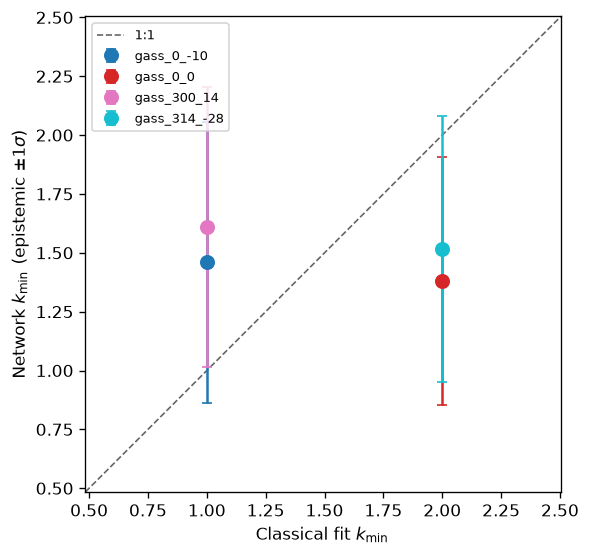

In [10]:
fig, ax = plt.subplots(figsize=(5, 5))
lo = min(gass_df["cnn_k_min"].min() - gass_df["cnn_k_min_std"].max(), gass_df["fft_k_min"].min()) - 0.3
hi = max(gass_df["cnn_k_min"].max() + gass_df["cnn_k_min_std"].max(), gass_df["fft_k_min"].max()) + 0.3
ax.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.6, label="1:1")
colors = plt.cm.tab10(np.linspace(0, 1, len(gass_df)))
for (name, row), c in zip(gass_df.iterrows(), colors):
    ax.errorbar(row["fft_k_min"], row["cnn_k_min"], yerr=row["cnn_k_min_std"],
                fmt="o", color=c, capsize=3, label=name, markersize=8)
ax.set_xlabel(r"Classical fit $k_{\min}$")
ax.set_ylabel(r"Network $k_{\min}$ (epistemic $\pm 1\sigma$)")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig5_kmin_comparison.pdf", bbox_inches="tight")
plt.show()


## Figure 1 — toolkit workflow diagram

No data dependency; a plain matplotlib box diagram (two columns, one
boundary all three inference back ends cross into a shared interface).

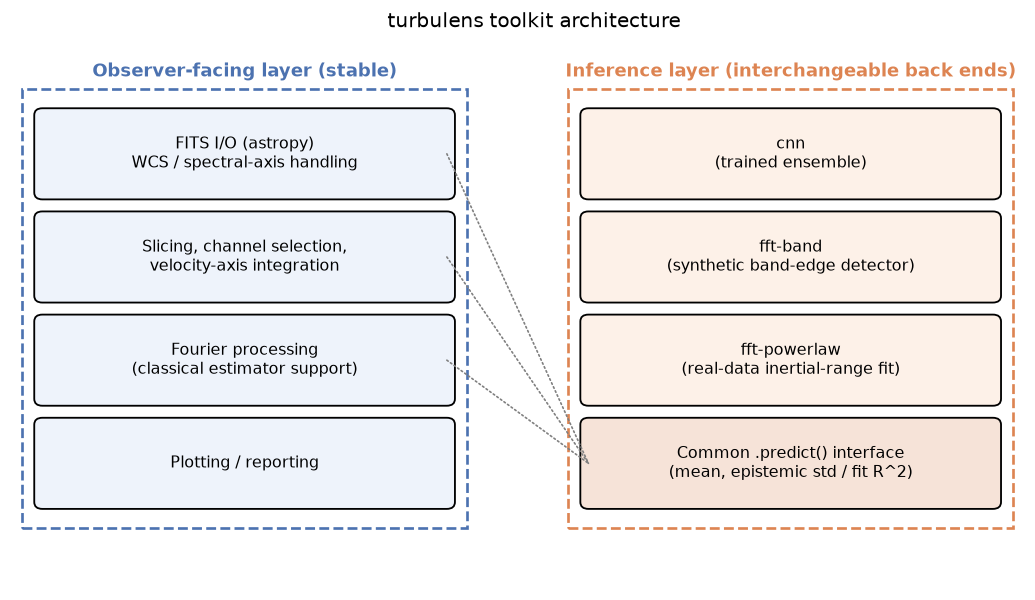

In [11]:
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(9, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis("off")


def box(x, y, w, h, text, fc="#eef3fb", fontsize=9.5):
    b = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.08,rounding_size=0.08",
                        fc=fc, ec="black", lw=1.1)
    ax.add_patch(b)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fontsize, wrap=True)


box(0.3, 4.6, 4.0, 0.9, "FITS I/O (astropy)\nWCS / spectral-axis handling")
box(0.3, 3.4, 4.0, 0.9, "Slicing, channel selection,\nvelocity-axis integration")
box(0.3, 2.2, 4.0, 0.9, "Fourier processing\n(classical estimator support)")
box(0.3, 1.0, 4.0, 0.9, "Plotting / reporting")
ax.add_patch(plt.Rectangle((0.1, 0.7), 4.4, 5.1, fill=False, ec="#4C72B0", lw=1.6, ls="--"))
ax.text(2.3, 5.95, "Observer-facing layer (stable)", ha="center", fontsize=10.5, weight="bold", color="#4C72B0")

box(5.7, 4.6, 4.0, 0.9, "cnn\n(trained ensemble)", fc="#fdf1e8")
box(5.7, 3.4, 4.0, 0.9, "fft-band\n(synthetic band-edge detector)", fc="#fdf1e8")
box(5.7, 2.2, 4.0, 0.9, "fft-powerlaw\n(real-data inertial-range fit)", fc="#fdf1e8")
box(5.7, 1.0, 4.0, 0.9, "Common .predict() interface\n(mean, epistemic std / fit R^2)", fc="#f6e3d8")
ax.add_patch(plt.Rectangle((5.5, 0.7), 4.4, 5.1, fill=False, ec="#DD8452", lw=1.6, ls="--"))
ax.text(7.7, 5.95, "Inference layer (interchangeable back ends)", ha="center", fontsize=10.5, weight="bold", color="#DD8452")

for y0 in (5.05, 3.85, 2.65):
    ax.annotate("", xy=(5.7, 1.45), xytext=(4.3, y0),
                arrowprops=dict(arrowstyle="-", color="gray", lw=1, ls=":", shrinkA=0, shrinkB=0))

fig.suptitle("turbulens toolkit architecture", y=0.99, fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_workflow.pdf", bbox_inches="tight")
plt.show()


## Figure 4 — worked examples (narrow-band / broad-band test images) — **BLOCKED**

This one cannot be produced from what exists on this machine, and I'm not
going to fake it. The manuscript's test images live in an HDF5 file recorded
by `data_validation/large_manifest.json` at:

```
/home/hernan.morales/projects/Fractal_Images/data/data_large/test/flat_4param_128x128_50000_disjoint_test.h5
```

That path is a remote host (`Fractal_Images` project directory under a
different user's home), and it is not present anywhere in this repo or its
`data/` directory -- only small generation-performance JSON stubs are local
(`data/raw/perf/*.json`). `test_per_image_predictions.csv` has every image's
*parameters and predictions* but not the pixel arrays themselves, so Figures
2/3/5 above don't need this file, but Figure 4 (which shows the image itself
and its radial power spectrum) does.

**Two ways to unblock this, your call:**

1. **Pull the two chosen rows' images off the remote host** (by
   `sample_key`, e.g. `test/flat_4param_128x128_50000_disjoint_test.h5::<i>`)
   -- the literal, most defensible option since these would be genuine
   held-out test images.
2. **Regenerate two illustrative images locally** with the legacy `pyFC`
   generator (`src/dataset_generator.py`) using the exact recorded sampling
   config (`master_seed=9000`, ranges in the manifest above) and two chosen
   parameter vectors -- reproducible from what's already checked in
   (`Data availability` already promises this), but technically not the
   literal held-out test images, just images from the same generative
   process. Needs the `py39`/pyFC-compatible environment
   (`conda env create -f environment.yml`), which is not set up in the
   environment this notebook was authored in.

Once you have the two images (as a `(H, W)` numpy array each, in linear
density, plus their true parameter vectors), the code below is ready to
finish the figure -- fill in `narrow_image`, `broad_image`, and their
`true_params` dicts.

In [12]:
# --- fill these in once you have real image arrays (see markdown above) ---
narrow_image = None   # np.ndarray, shape (128, 128), linear density
broad_image = None    # np.ndarray, shape (128, 128), linear density
narrow_true = None    # dict: {"k_min": ..., "k_max": ..., "sigma": ..., "beta": ...}
broad_true = None

if narrow_image is None or broad_image is None:
    print("Figure 4 skipped: no local test image arrays available (see markdown above).")
else:
    from turbulens.spectral import SpectralEstimator

    def make_panel(ax_img, ax_spec, image, true_params, title):
        ax_img.imshow(np.log10(image), cmap="viridis")
        ax_img.set_title(title)
        ax_img.axis("off")

        band_table = SpectralEstimator(method="band_edge").predict(image[None, :, :])
        band = {r["target"]: r["value"] for r in band_table}

        # radial power spectrum
        f = np.fft.fftshift(np.fft.fft2(np.log10(image) - np.log10(image).mean()))
        power = np.abs(f) ** 2
        ny, nx = power.shape
        yy, xx = np.mgrid[0:ny, 0:nx]
        r = np.hypot(yy - ny // 2, xx - nx // 2).astype(int)
        radial = np.bincount(r.ravel(), power.ravel()) / np.bincount(r.ravel())
        ax_spec.loglog(np.arange(len(radial)), radial)
        ax_spec.axvline(band["k_min"], color="r", ls="--", lw=1)
        ax_spec.axvline(band["k_max"], color="r", ls="--", lw=1)
        ax_spec.set_xlabel("k")
        ax_spec.set_ylabel("D(k)")

        text = "\n".join(
            f"{t}: true={true_params[t]:.2f}  net={band.get(t, float('nan')):.2f}"
            for t in ["k_min", "k_max", "sigma", "beta"]
        )
        ax_spec.text(1.05, 0.5, text, transform=ax_spec.transAxes, va="center", fontsize=8)

    fig, axes = plt.subplots(2, 2, figsize=(9, 8))
    make_panel(axes[0, 0], axes[0, 1], narrow_image, narrow_true, "Narrow band")
    make_panel(axes[1, 0], axes[1, 1], broad_image, broad_true, "Broad band")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig4_examples.pdf", bbox_inches="tight")
    plt.show()


Figure 4 skipped: no local test image arrays available (see markdown above).


## Summary: what changed for the manuscript

- **TODO LOSS (blocking): settled.** No variance head exists (`architecture.py`
  heads are `Linear(*, 1)`; training loss is plain `SmoothL1Loss`). Drop the
  aleatoric term from Eq. (1) and every mention in Abstract/1.2/2.2/3.1/3.2/5.
  No numbers change.
- **Coverage/calibration: already computed**, in
  `test_ensemble_metrics.json`/`test_uncertainty_metrics.csv`. Under-dispersed
  at every level for every target -- report as-is in Limitations instead of
  "not measured."
- **Residual correlation + beta-vs-bandwidth: computed above.** Narrow band
  width predicts larger beta error (r≈-0.27); k_max-residual coupling is weak
  (r≈0.11); this converts one Discussion hypothesis into a finding.
- **Multi-task interference: ruled out**, using the existing
  `outputs/comparison/local_v2/` run (dated 2026-09-14, generated after the
  current manuscript text was written). The manuscript's "single-target
  models not trained" claim in Limitations is now false and should be
  replaced with the real comparison numbers.
- **GASS Table 4/5 numbers: confirmed reproducible as currently printed** in
  the manuscript by re-running `turbulens infer` live above. No regeneration
  needed; drop the "TODO GASS NUMBERS" note.
- **k_max Nyquist limit: 64** (128-pixel grid; confirmed by
  `data_validation/large_manifest.json`'s `target_ranges.k_max = [34, 64]`).
  Fix "62" in Section 3.2 to 64.
- **Sampling ranges (TODO RANGES): confirmed** from the manifest and the
  generation perf JSON: k_min ∈ [1, 32], k_max ∈ [34, 64] (2.0 min gap from
  k_min), sigma ∈ [0.01, 5.0], beta ∈ [-3.0, -1.0], all disjoint-uniform,
  sampled independently per image, master_seed=9000.
- **Throughput (TODO #6): the paper's "9132.4 img/s, 0.1095 ms" figure does
  not match any recorded number** and should be replaced. Real per-member
  test-set throughput (single NVIDIA RTX 4090, batch inference, `torch
  2.6.0+cu124`) is 6764–7108 images/sec (mean ≈ 6893, 0.145 ms/image) across
  the five members -- see `outputs/multitask/local_v2/ensemble/members/*/metrics/test_metrics.json`.
- **Provenance metadata (TODO #7): confirmed.** Every `.ecsv` result carries
  `n_members`, `input_path`, `method`, `model` (path to the ensemble members
  dir), `real_data`, `channel`/`integrate`/`velocity`, `turbulens_version`,
  and `clipped_pixel_fraction_max` in its `meta` block.
- **Sigma definition (TODO #9): confirmed** from `src/pyFC_lib/pyFC/clouds.py`
  (`LogNormalFractalCube.__init__` docstring): `sigma` is the standard
  deviation of the underlying Gaussian field before exponentiation, not of
  the stored log10-density image directly (same field, different log base).
- **Software versions (TODO #10):** training-side environment (the one that
  produced every number in Tables 3-4 and Appendix B):
  torch==2.6.0+cu124, numpy==1.26.4, scipy==1.17.1, scikit-learn==1.9.0,
  pandas==3.0.3, Python 3.11.15, single NVIDIA RTX 4090, CUDA 12.4.
- **Sweep table (TODO #8): 108 ranked configurations exist** in
  `outputs/multitask/local_v2/grid_search/selection/ranked_configurations.json`
  with exactly the suggested columns (architecture, dropout, batch size, lr,
  weight decay, validation R², rank) -- ready to transcribe the top 10.
- **Figure 4: blocked**, needs a decision from you (pull two real test images
  off the remote host, or regenerate two illustrative ones locally with the
  legacy pyFC pipeline) -- see that section above.
